# Lung anatomical frame and section provenance audit

Compare the existing v25 lung geometry with the deposited lapdMouse m07 labelmap, then produce a version 26 viewer with explicit reference-frame and Xenium section uncertainty. This anatomical reference audit does not use cell segmentation or assign Xenium tissue to an atlas plane. The m07 lobe segmentation is an external organ-level reference, unrelated to Xenium cell segmentation.

The de Lima Immunity methods describe 5 µm FFPE sections but do not specify lobe identity, block-face orientation or depth in the inspected spatial-transcriptomics methods. An image-plane location within a Xenium section cannot determine the 3D cutting plane. D14 and D30 must remain unregistered unless external orientation evidence is found.

Sources: supplied v25 HTML; de Lima et al., DOI 10.1016/j.immuni.2026.01.023; lapdMouse m07, https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07; lobe labels 1 left, 2 cranial, 3 middle, 4 caudal, 5 accessory. The supplied Garcia PDF (DOI 10.1152/japplphysiol.00028.2020) is an editorial; Bauer et al. (DOI 10.1152/japplphysiol.00615.2019) is the primary archive publication. The m07 labelmap header explicitly uses left-posterior-superior coordinates in mm.

**Path migration:** prior viewer versions were moved byte-for-byte into this repository under `viewer/archive`. Source/output paths below were updated after the last scientific execution; this path-only edit was not followed by a full rerun of notebook 16. Use notebook 17 for v28. The migration manifest records original and current paths and hashes.

## Reproduce this workflow on another section

**Purpose:** propose reviewable reference-plane hypotheses from a section outline; regenerate the 3D viewer and exact 2D mesh cuts. This notebook does not infer a unique anatomical registration from tissue shape.

1. Run from the project root using the `xenium_rebuild` Python environment and Node.js. Local inputs are read-only: v25 mesh HTML, m07 lobe NRRD, cached body OBJ and section images. Paths and missing-file errors identify required inputs. Data sources are linked below; this notebook does not silently download large volumes.
2. Run all cells in order. For an alternate destination set `LUNG_VIEWER_OUTPUT` before execution. The default final viewer is v27, keeping v26 intact. Notebook outputs contain the diagnostic figures and execution evidence.
3. In **USER CONFIGURATION**, add a named entry to `SECTION_INPUTS`. For pyramid TIFF select `level` and `page`; PNG/JPEG is read as grayscale. A supplied binary `manual_mask` is resized with nearest-neighbor interpolation and used without automatic hole filling. Inspect masks before trusting the ranking.
4. Start with the documented coarse grid. Refine `AZIMUTHS`, `ELEVATIONS`, `OFFSETS_MM` and `PLANE_GRID_MM` around several alternatives, not just the leading result. Lower `LABEL_STRIDE` improves volume detail at a memory/runtime cost. Scale is free in this first screening; no physical size matching is claimed.
5. Read the observed-mask plot and normalized overlap panels (gray agreement, red observed-only, blue reference-only). PCA sets only in-plane orientation; reflection and uniform rescaling are allowed. IoU ranks outlines; near-equal scores should retain multiple hypotheses. Neither a top score nor a model lobe label establishes the sampled lobe.
6. Candidate JSON includes angles, signed offset, source-lobe hypothesis, score and portable `plane_id`. Paste that ID into v27 to review the full mesh cut. Other lobes may also intersect this plane because single-lobe hypotheses assume that one lobe was sampled separately. Additional section names are available through JSON IDs; the viewer's two named buttons remain D14 and D30.
7. Validate with independent branch/lumen landmarks, serial sections, orientation notes or same-specimen 3D images before treating a hypothesis as anatomy. Current hole/airway correspondence is not scored. Record any biological interpretation separately from geometry.

The LP1 frame is fixed by the full geometry hash and the source coordinate origin, not an external universal mouse atlas. Whole-body display fitting does not affect IDs. All implementation stays in this English notebook; no analysis helper scripts are required.

**Expected outputs:** frame audit; reference and observed-section figures; exact plane-intersection QC; exploratory candidate JSON/figure; v27 HTML; versioned build/validation report. The final viewer has local-file clipboard fallback and portable IDs; local-path links require a matching file location. Live browser rendering has not been validated by automation.

In [1]:
from pathlib import Path
import json,re,gzip,base64,hashlib,itertools,io
import numpy as np
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
SRC=ROOT/'viewer/archive/mouse_lung_3d_blender_detail_v25_clip_exact_plane.html'
REF=ROOT/'data/m07/m07_Lobes.nrrd'
OUT=ROOT/'qa/anatomical_frame';OUT.mkdir(parents=True,exist_ok=True)
source=SRC.read_text();payload=json.loads(re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',source,re.S).group(1))
labels={1:'Left lobe',2:'Right cranial lobe',3:'Right middle lobe',4:'Right caudal lobe',5:'Right accessory lobe'}
with REF.open('rb') as f:
 header=b''
 while not header.endswith(b'\n\n'):header+=f.read(1)
 offset=f.tell()
header=header.decode();print(header)
sizes=tuple(map(int,re.search(r'^sizes: (.*)$',header,re.M)[1].split()))
spacing=np.array([float(v) for v in re.search(r'^space directions: (.*)$',header,re.M)[1].replace('(','').replace(')','').replace(',',' ').split()]).reshape(3,3).diagonal()
origin=np.fromstring(re.search(r'^space origin: \((.*?)\)',header,re.M)[1],sep=',')
assert 'space: left-posterior-superior' in header
mins={i:np.full(3,np.inf) for i in labels};maxs={i:np.full(3,-np.inf) for i in labels};counts={i:0 for i in labels};sums={i:np.zeros(3) for i in labels}
with REF.open('rb') as raw:
 raw.seek(offset)
 with gzip.GzipFile(fileobj=raw) as f:
  for z in range(sizes[2]):
   arr=np.frombuffer(f.read(sizes[0]*sizes[1]*2),dtype='<u2').reshape(sizes[1],sizes[0])
   for label in labels:
    yy,xx=np.nonzero(arr==label)
    if not len(xx):continue
    mins[label]=np.minimum(mins[label],[xx.min(),yy.min(),z]);maxs[label]=np.maximum(maxs[label],[xx.max(),yy.max(),z])
    counts[label]+=len(xx);sums[label]+=[xx.sum(),yy.sum(),z*len(xx)]
reference={labels[i]:{'min':(origin+mins[i]*spacing).tolist(),'max':(origin+maxs[i]*spacing).tolist(),'centroid':(origin+sums[i]/counts[i]*spacing).tolist(),'voxels':counts[i]} for i in labels}
(OUT/'reference_lobe_bounds.json').write_text(json.dumps(reference,indent=2))
print(json.dumps(reference,indent=2))

NRRD0004
# Complete NRRD file format specification at:
# http://teem.sourceforge.net/nrrd/format.html
type: unsigned short
dimension: 3
space: left-posterior-superior
sizes: 1009 855 1199
space directions: (0.018559999763965603,0,0) (0,0.018559999763965603,0) (0,0,0.019039999693632119)
kinds: domain domain domain
endian: little
encoding: gzip
space origin: (5.219999999999998,2.3060800000000006,0.0095199999999999989)


{
  "Left lobe": {
    "min": [
      16.09615986168384,
      4.811679968135357,
      1.2280799803924556
    ],
    "max": [
      23.687199765145774,
      15.409439833359716,
      17.697679715384236
    ],
    "centroid": [
      20.118975416473177,
      11.405833153412637,
      9.543152747731334
    ],
    "voxels": 56045858
  },
  "Right cranial lobe": {
    "min": [
      7.484319971203801,
      5.182879963414669,
      10.15783983670592
    ],
    "max": [
      15.76207986593246,
      17.07983981211662,
      19.182799691487542
    ],
    "centroid": [
     

In [2]:
# Test all signed axis permutations with one shared translation; no per-lobe shifts.
names=list(labels.values());local={d['name']:d for d in payload}
rlo=np.array([reference[n]['min'] for n in names]);rhi=np.array([reference[n]['max'] for n in names])
slo=np.array([local[n]['min'] for n in names]);shi=np.array([local[n]['max'] for n in names])
fits=[]
for perm in itertools.permutations(range(3)):
 for signs in itertools.product([-1,1],repeat=3):
  sg=np.array(signs);a=rlo[:,perm]*sg;b=rhi[:,perm]*sg;lo=np.minimum(a,b);hi=np.maximum(a,b)
  shift=np.mean(((slo+shi)-(lo+hi))/2,axis=0)
  error=np.sqrt(np.mean(np.r_[slo-lo-shift,shi-hi-shift]**2))
  fits.append({'perm':list(perm),'signs':list(signs),'translation':shift.tolist(),'bbox_rmse_mm':float(error)})
fits.sort(key=lambda r:r['bbox_rmse_mm']);best=fits[0]
print('Best LPS -> v25 mesh transform:',best)
print('Runner up:',fits[1])
(OUT/'geometry_frame_audit.json').write_text(json.dumps({'best_transform':best,'runner_up':fits[1],'source_v25_sha256':hashlib.sha256(SRC.read_bytes()).hexdigest(),'reference_sha256':hashlib.sha256(REF.read_bytes()).hexdigest(),'method':'all 48 signed axis permutations; global translation only; five label bounding boxes'},indent=2))

Best LPS -> v25 mesh transform: {'perm': [0, 1, 2], 'signs': [-1, -1, 1], 'translation': [15.166304216235872, 10.236768446015118, -11.94307390913784], 'bbox_rmse_mm': 0.018576082252190266}
Runner up: {'perm': [0, 1, 2], 'signs': [-1, 1, 1], 'translation': [15.166304216235872, -9.93238335614085, -11.94307390913784], 'bbox_rmse_mm': 1.8600134973418816}


## Interpretation of the reference comparison

The best bounding-box transform from m07 LPS to the v25 local mesh frame is `(-L, -P, +S)` plus a single translation, with about 0.019 mm RMS residual (one reference voxel). The next-best sign assignment has about 1.86 mm residual. This strongly supports an m07-derived shape/orientation match; bounding boxes alone are not proof of mesh-file provenance. In the local mesh frame +Y is ventral, and the middle/accessory lobes already lie ventral to the caudal lobe. Therefore v26 preserves every lobe vertex and airway connection. It starts in a stationary ventral view, makes the two ventral lobes easy to isolate, and separates actual Xenium section evidence from the illustrative 3D plane. No unsupported per-lobe translation is introduced.

In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
import tifffile
# Orthographic depth projection of the actual source surface vertices.
cloud=[];colors=[];vlocal={}
for d in payload:
 if d['name'] not in names:continue
 q=np.frombuffer(gzip.decompress(base64.b64decode(d['q_b64'])),dtype='<u2').reshape(-1,3)
 v=np.array(d['min'])+q/65535*(np.array(d['max'])-np.array(d['min']))
 vlocal[d['name']]=v;cloud.append(v);colors.append(np.tile(d['color'],(len(v),1)))
v=np.vstack(cloud);rgb=np.vstack(colors)
fig,axs=plt.subplots(1,2,figsize=(11,7));fig.subplots_adjust(bottom=.20,wspace=.28)
fig.suptitle('Surface-vertex depth projection (not a Xenium section)',fontsize=11)
for ax,side in zip(axs,['Ventral','Dorsal']):
 width=580;height=620
 xx=-v[:,0] if side=='Ventral' else v[:,0];zz=v[:,2]
 ix=np.clip(((xx+9)/18*(width-1)).astype(int),0,width-1);iz=np.clip(((11-zz)/22*(height-1)).astype(int),0,height-1)
 pixel=iz*width+ix;depth=v[:,1]*(1 if side=='Ventral' else -1)
 order=np.lexsort((depth,pixel));pix=pixel[order];last=np.r_[pix[1:]!=pix[:-1],True];sel=order[last]
 canvas=np.full((height*width,3),.95);canvas[pixel[sel]]=rgb[sel];canvas=canvas.reshape(height,width,3)
 ax.imshow(canvas,extent=[-9,9,-11,11]);ax.set_title(side+' reference view');ax.set_xlabel('Display horizontal coordinate (mm)');ax.set_ylabel('Cranial (+) / caudal (-), model mm')
fig.legend(handles=[Patch(color=local[name]['color'],label=name) for name in names],loc='lower center',ncol=3,bbox_to_anchor=(.5,.01),fontsize=9)
fig.savefig(OUT/'lobe_orientation_audit.png',dpi=160,bbox_inches='tight');plt.close(fig)
# Small section thumbnails preserve the acquired 2D orientation; no 3D registration.
thumbs={}
fig,axs=plt.subplots(1,2,figsize=(10,5),constrained_layout=True)
for ax,day in zip(axs,['D14','D30']):
 path=ROOT/f'data/xenium_optional/{day}/explorer/morphology_focus/morphology_focus_0000.ome.tif'
 with tifffile.TiffFile(path,is_ome=False) as tf:im=tf.series[0].levels[4].pages[0].asarray()
 lo,hi=np.percentile(im,[1,99.7]);im8=np.uint8(np.clip((im.astype(float)-lo)/max(hi-lo,1),0,1)*255)
 image=Image.fromarray(im8);image.thumbnail((720,640));buf=io.BytesIO();image.save(buf,format='PNG');thumbs[day]='data:image/png;base64,'+base64.b64encode(buf.getvalue()).decode()
 ax.imshow(im8,cmap='gray');ax.set_title(day+' | 3D plane and lobe unregistered');ax.axis('off')
fig.savefig(OUT/'xenium_section_comparison.png',dpi=130);plt.close(fig)
print('Rendered actual mesh views and both section thumbnails.')

Rendered actual mesh views and both section thumbnails.


## Render-frame correction and section evidence

The v25 scene applies `modelMirroredLR=true`, a second left/right reflection after loading the meshes. This reverses the expected ventral gross-anatomy presentation. V26 removes that scene reflection, updates lateral camera directions and side hints, and starts with rotation paused. The middle/accessory-only button changes visibility, never vertices. Plane coordinates retain their local (+right,+ventral,+cranial) model frame, with mm units; no day-specific section plane is inferred.

Both public GEO records (GSM8837316 and GSM9364368) independently describe 5 µm FFPE sections but contain no lobe, plane, depth or embedding-orientation fields. The main paper and supplements were searched for lobe/sagittal/coronal/transverse/orientation terms. Determining the actual plane requires a block-face/embedding record, oriented serial sections, or correspondence to a specimen-specific 3D scan. A shape match to this unrelated normal m07 lung would at most be a hypothesis.

In [4]:
import os,subprocess
samples={}
for day,acc in [('D14','GSM8837316'),('D30','GSM9364368')]:
 text=(REF.parent/f'{acc}.soft.txt').read_text()
 samples[day]={'accession':acc,'title':re.search(r'!Sample_title = (.*)',text)[1],'section_thickness_um':5,'lobe':'not_reported','plane':'unregistered','depth':'not_reported','orientation_terms_found':re.findall(r'\b(?:lobe|sagittal|coronal|transverse|orientation)\b',text,re.I)}
 assert not samples[day]['orientation_terms_found']
(OUT/'section_provenance.json').write_text(json.dumps(samples,indent=2))
viewer=source

def replace_one(old,new):
 global viewer
 assert viewer.count(old)==1,(old[:80],viewer.count(old))
 viewer=viewer.replace(old,new)
replace_one('const modelMirroredLR=true;','const modelMirroredLR=false; // v26: preserve reference anatomical handedness')
replace_one('controls.autoRotate=true; controls.autoRotateSpeed=1.00;','controls.autoRotate=false; controls.autoRotateSpeed=1.00;')
replace_one('let autoRotateStoppedByUser=false;','let autoRotateStoppedByUser=true;')
replace_one("autoRotateStoppedByUser=false; controls.autoRotate=true; setResumeButton();", "autoRotateStoppedByUser=false; controls.autoRotate=true; currentView='Custom'; updateSideHint(currentView); setResumeButton();")
replace_one("left:new THREE.Vector3(1,0,.07),right:new THREE.Vector3(-1,0,.07)","left:new THREE.Vector3(-1,0,.07),right:new THREE.Vector3(1,0,.07)")
viewer=viewer.replace('Ventral view: screen-left = mouse LEFT lung · screen-right = mouse RIGHT lung','Ventral view: screen-left = mouse RIGHT lung · screen-right = mouse LEFT lung')
viewer=viewer.replace('Dorsal view: screen-left = mouse RIGHT lung · screen-right = mouse LEFT lung','Dorsal view: screen-left = mouse LEFT lung · screen-right = mouse RIGHT lung')
replace_one("currentView=presetLabel[b.dataset.view]||'Custom'; updateSideHint", "stopAutoRotateByUser(); currentView=presetLabel[b.dataset.view]||'Custom'; updateSideHint")
replace_one("addEventListener('click',()=>{currentView='Ventral'; updateSideHint", "addEventListener('click',()=>{stopAutoRotateByUser(); currentView='Ventral'; updateSideHint")
replace_one('C57BL/6J mouse strain · Blender-derived lung surfaces','v26 · C57BL/6 m07 anatomical reference')
replace_one('<h1>Mouse lung explorer</h1>','<h1>Mouse lung explorer · v26</h1>')
replace_one('Detailed lung and airway meshes, reproducible quadruped plane naming, an optional public CT-derived whole-mouse context mesh, and a gentle automatic turntable rotation.','Stationary ventral view. Reference lobe positions are preserved. Day 14 / 30 sections have no established 3D registration.')
replace_one('Section plane · quadruped / NAV','Illustrative reference plane · not D14 / D30')
replace_one('Coordinates & NAV base','Model coordinates (mm) & NAV base')
replace_one('Offset 0.00 · through model origin','Offset 0.00 mm · through model origin')
replace_one('toFixed(2)} toward ${info.offSide}','toFixed(2)} mm toward ${info.offSide}')
replace_one('<button id="toggleSection" class="primary">Hide plane</button>','<button id="toggleSection" class="primary">Show plane</button>')
replace_one('let sectionVisible=true,sectionDepth=0,sectionAngle=15,sectionTilt=0;','let sectionVisible=false,sectionDepth=0,sectionAngle=15,sectionTilt=0; sectionGroup.visible=false;')
replace_one('  <section id="ui" class="panel">','  <section id="ui" class="panel" style="max-height:calc(100vh - 32px);overflow:auto">')
replace_one('    <div class="control"><label for="depth">',"""    <div class="btnGrid two"><button id="focusVentralLobes">Middle + accessory only</button><button id="showD14">Day 14 section</button><button id="showD30">Day 30 section</button></div>
    <div class="small">Lobes keep their measured positions. The two small ventral lobes can be isolated without moving them.</div>
    <div class="control"><label for="depth">""")
replace_one('  <div id="orientation" class="panel">',"""  <aside id="sectionEvidence" class="panel" hidden style="right:16px;top:105px;width:min(430px,calc(100vw - 32px));max-height:calc(100vh - 130px);overflow:auto;padding:14px;z-index:40">
    <button id="closeSectionEvidence" style="float:right">Close</button><h2 id="sectionEvidenceTitle" style="font-size:16px"></h2>
    <img id="sectionEvidenceImage" alt="Observed Xenium DAPI section; 3D orientation unknown" style="width:100%;margin-top:8px;background:black">
    <p class="small" id="sectionEvidenceText"></p><p class="small">The plane controls explore this unrelated m07 reference. Selecting a day does not place that section on the 3D model. Required evidence: oriented block face, serial sections, or a specimen-specific 3D registration.</p>
  </aside>
  <div id="orientation" class="panel">""")
replace_one('        <li><b>Lung and airway surfaces.</b> Viewer surfaces were derived directly from the supplied Blender lung / airway meshes used in this project.</li>',"""        <li><b>Lung geometry audit (v26).</b> Five lobe bounding boxes match lapdMouse m07 within 0.019 mm RMS after a common axis transform and translation. Lobe vertices are unchanged. The v25 rendering-only left/right reflection is removed. Middle and accessory lobes are already ventral to the caudal lobe.</li>
        <li><b>lapdMouse reference.</b> Bauer et al., J Appl Physiol (2020), doi:10.1152/japplphysiol.00615.2019. <a href="https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07" target="_blank">m07 archive</a>, male C57BL/6; CC BY 4.0. Beichel et al., Lung anatomy + particle deposition mouse archive, doi:10.25820/9arg-9w56.</li>
        <li><b>Xenium section evidence.</b> de Lima et al., Immunity (2026), doi:10.1016/j.immuni.2026.01.023. GEO GSM8837316 (D14) and GSM9364368 (D30): 5 µm FFPE sections. Lobe, plane, depth and embedding orientation are not recorded in the inspected methods or sample descriptions.</li>""")
js="""
  // v26 visibility aid and unregistered source-section panel.
  const dayThumbnails=__THUMBS__;
  let ventralLobesOnly=false;
  const isVentralLobe=m=>['Right middle lobe','Right accessory lobe'].includes(m.name);
  function applyLobeVisibility(){const enabled=document.getElementById('lobesVisible').checked;lobeMeshes.forEach(m=>m.visible=enabled&&(!ventralLobesOnly||isVentralLobe(m)));}
  document.getElementById('focusVentralLobes').addEventListener('click',e=>{
    ventralLobesOnly=!ventralLobesOnly;clearSelection();document.getElementById('lobesVisible').checked=true;applyLobeVisibility();
    e.currentTarget.textContent=ventralLobesOnly?'Restore all lobes':'Middle + accessory only';e.currentTarget.classList.toggle('active',ventralLobesOnly);
    stopAutoRotateByUser();currentView='Ventral';updateSideHint(currentView);flyCamera(viewPosition('ventral'),activeCenter());
  });
  function showSection(day){const panel=document.getElementById('sectionEvidence');panel.hidden=false;
    document.getElementById('sectionEvidenceTitle').textContent=day+' · section plane unknown';
    document.getElementById('sectionEvidenceImage').src=dayThumbnails[day];
    document.getElementById('sectionEvidenceText').textContent=(day==='D14'?'GSM8837316':'GSM9364368')+' | acquired 2D DAPI orientation | FFPE, 5 µm. Lobe: not reported. Plane normal, offset and block depth: not established.';
  }
  document.getElementById('showD14').addEventListener('click',()=>showSection('D14'));
  document.getElementById('showD30').addEventListener('click',()=>showSection('D30'));
  document.getElementById('closeSectionEvidence').addEventListener('click',()=>document.getElementById('sectionEvidence').hidden=true);
""".replace('__THUMBS__',json.dumps(thumbs))
replace_one("  const opacity=document.getElementById('opacity')",js+"\n  const opacity=document.getElementById('opacity')")
replace_one('lobeMeshes.forEach(m=>m.visible=e.target.checked);','applyLobeVisibility();')
assert re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S)[1]==re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',source,re.S)[1]
DEST=ROOT/'viewer/archive/mouse_lung_3d_blender_detail_v27_anatomy_reference.html'
BUILD=Path(os.environ.get('LUNG_VIEWER_OUTPUT',str(DEST)))
BUILD.write_text(viewer)
module=re.search(r'<script type="module">(.*?)</script>',viewer,re.S)[1]
check=subprocess.run(['node','--input-type=module','--check'],input=module,text=True,capture_output=True);assert check.returncode==0,check.stderr
report={'output_path':str(DEST),'output_sha256':hashlib.sha256(viewer.encode()).hexdigest(),'geometry_payload_unchanged':True,'left_right_render_reflection_removed':True,'default_rotation':False,'default_view':'ventral','model_bbox_fit':best,'section_provenance':samples,'browser_live_test':'not_performed_local_file_URL_blocked','reference':{'url':'https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07','license':'CC BY 4.0'}}
(OUT/'v27_build_report.json').write_text(json.dumps(report,indent=2))
print('Built:',BUILD,'bytes:',BUILD.stat().st_size)
print('JavaScript syntax passed; compressed geometry payload unchanged.')

Built: /private/tmp/mouse_lung_3d_blender_detail_v27_anatomy_reference.html bytes: 33664197
JavaScript syntax passed; compressed geometry payload unchanged.


## Whole-body context: dorsal/ventral frame correction

The separate MAMMAL/SAM body OBJ has its head toward +Z and its back toward +Y: in the sagittal projection, paws lie toward low Y and the arched back toward high Y. The lung viewer uses +Y ventral. Loading this body with no rotation therefore presents the back in the ventral view. Apply a proper 180-degree rotation around Z (`diag(-1,-1,1)`, determinant +1) to the body geometry before bounding-box fitting. This retains the cranial direction and handedness. The symmetric body surface cannot independently establish left/right identity.

Source: https://github.com/anl13/MAMMAL_mouse (model extracted from SAM C57BL6 Female v1.2). The lung and body are from different sources. Existing anisotropic body sizing and heuristic thorax placement are illustrative, not a CT registration or a basis for Xenium plane assignment. Compute the anchor after the final scale to avoid the previous scale/translation ordering error. Visual validation below is a static mesh projection, not a live browser test.


### Size and position in body mode
The old anisotropic body stretch and clamped lung magnification are removed. The body uses one uniform display scale (11.8; not a verified mm calibration). A conservative thorax envelope is selected from the visible body landmarks: rotated source coordinates X=[-0.85,0.85], Y=[-1.65,-0.30], Z=[0.55,2.35]. The lobes fit uniformly within 90% of this envelope. Translation subtracts the scaled lobe bounding-box center. These are transparent illustration parameters, not measured ribs, diaphragm or a specimen registration. Lung-only coordinates remain unchanged.

Proper rotation verified; head direction and source distances preserved.


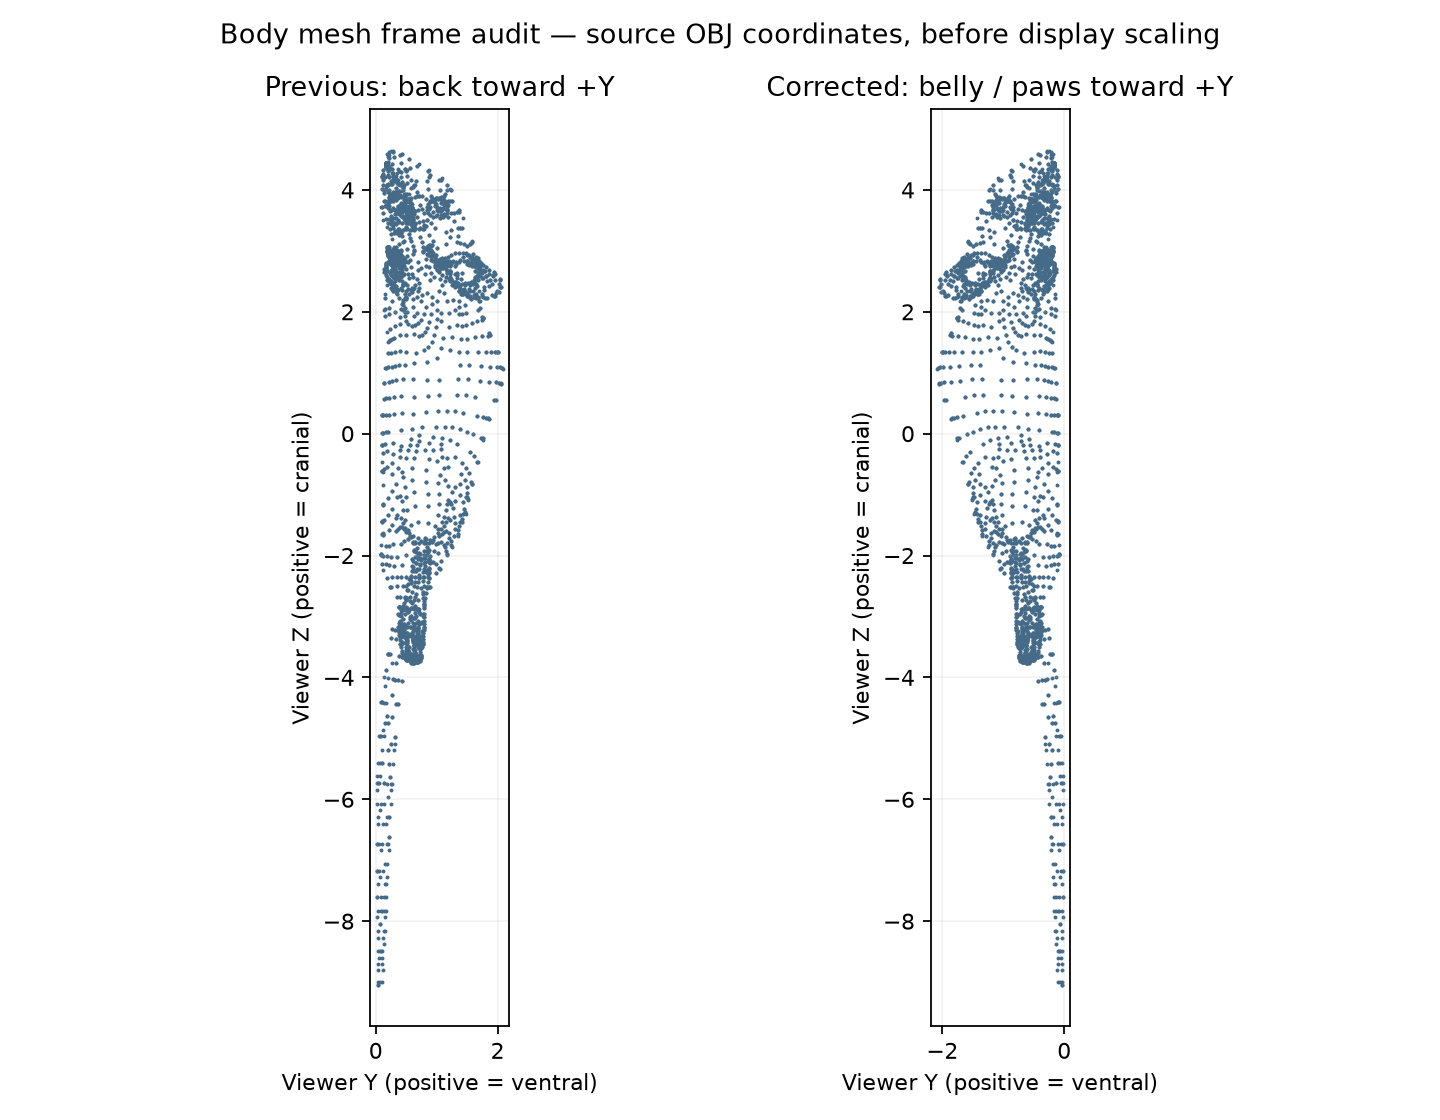

In [5]:
from pathlib import Path
import os, re, json, hashlib, subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
OUT = ROOT / 'qa/anatomical_frame'
body_path = ROOT / 'data/m07/mouse_reduced_face_7200.obj'
vertices = np.array([[float(x) for x in line.split()[1:4]] for line in body_path.read_text().splitlines() if line.startswith('v ')])
rotation = np.diag([-1., -1., 1.])
corrected = vertices @ rotation.T
assert np.linalg.det(rotation) == 1
assert np.allclose(corrected[:, 2], vertices[:, 2])
assert np.allclose(np.linalg.norm(corrected, axis=1), np.linalg.norm(vertices, axis=1))
fig, axes = plt.subplots(1, 2, figsize=(9, 7))
for ax, points, title in zip(axes, [vertices, corrected], ['Previous: back toward +Y', 'Corrected: belly / paws toward +Y']):
    ax.scatter(points[:, 1], points[:, 2], s=0.6, color='#466b88')
    ax.set(xlabel='Viewer Y (positive = ventral)', ylabel='Viewer Z (positive = cranial)', title=title)
    ax.set_aspect('equal'); ax.grid(alpha=.15)
fig.suptitle('Body mesh frame audit — source OBJ coordinates, before display scaling')
fig.tight_layout()
figure_path = OUT / 'body_orientation_audit.png'
fig.savefig(figure_path, dpi=160); plt.close(fig)
display(Image(filename=str(figure_path)))
print('Proper rotation verified; head direction and source distances preserved.')

In [6]:
DEST = ROOT/'viewer/archive/mouse_lung_3d_blender_detail_v27_anatomy_reference.html'
BUILD = Path(os.environ.get('LUNG_VIEWER_OUTPUT', str(DEST)))
viewer = BUILD.read_text()
original_payload = re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>', viewer, re.S)[1]
def patch_once(old, new):
    global viewer
    assert viewer.count(old) == 1, old
    viewer = viewer.replace(old, new, 1)
patch_once('let g=node.geometry;', 'let g=node.geometry.clone();\n          // Body source +Y is dorsal; viewer +Y is ventral. Proper rotation, not reflection.\n          g.rotateZ(Math.PI);')
start = viewer.index('      temp.scale.setScalar(11.8);')
end = viewer.index('      mouseContextGroup.clear();', start)
viewer = viewer[:start] + """      // Uniform display conversion; OBJ units are not calibrated physical mm.
      temp.scale.setScalar(11.8);
      temp.position.set(0,0,0);
      temp.rotation.set(0,0,0);
""" + viewer[end:]
start = viewer.index('      mouseThoraxTargetCenter.set(')
end = viewer.index('      updateContextLungFit();', start)
viewer = viewer[:start] + """      // Surface-landmark thorax envelope in rotated source-body units.
      // Inferior to neck/forelimb roots, superior to abdominal bulge; approximate.
      const thoraxMin=new THREE.Vector3(-0.85,-1.65,0.55).multiplyScalar(11.8);
      const thoraxMax=new THREE.Vector3(0.85,-0.30,2.35).multiplyScalar(11.8);
      mouseThoraxTargetCenter.copy(thoraxMin).add(thoraxMax).multiplyScalar(0.5);
      mouseThoraxFitSize.copy(thoraxMax).sub(thoraxMin);
""" + viewer[end:]
start = viewer.index('  function updateContextLungFit(){')
end = viewer.index('  updateContextLungFit();', start)
viewer = viewer[:start] + """  function updateContextLungFit(){
    const bounds=new THREE.Box3();
    lobeMeshes.forEach(mesh=>bounds.union(mesh.geometry.boundingBox));
    const size=bounds.getSize(new THREE.Vector3());
    const center=bounds.getCenter(new THREE.Vector3());
    // Uniform lobe fit; no arbitrary minimum, extra magnification or axis stretching.
    lungContextScale=0.90*Math.min(mouseThoraxFitSize.x/size.x,mouseThoraxFitSize.y/size.y,mouseThoraxFitSize.z/size.z);
    lungContextPosition.copy(mouseThoraxTargetCenter).addScaledVector(center,-lungContextScale);
    if(mouseContextGroup.visible) applyLungPlacement(true);
  }
""" + viewer[end:]
patch_once('aligned around the thorax and rendered', 'rotated into the lung anatomical frame; its uniformly scaled thorax placement is illustrative, not a registered CT overlay, and it is rendered')
patch_once('<li><b>Whole-mouse CT context mesh.</b>', '<li><b>Whole-body orientation correction.</b> The source body has +Y dorsal. A 180-degree rotation around Z aligns it with +Y ventral while preserving the cranial direction. Body placement is approximate; no specimen-specific CT registration is available.</li>\n        <li><b>Whole-mouse CT context mesh.</b>')
assert re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>', viewer, re.S)[1] == original_payload
module = re.search(r'<script type="module">(.*?)</script>', viewer, re.S)[1]
check = subprocess.run(['node','--input-type=module','--check'], input=module, text=True, capture_output=True)
assert check.returncode == 0, check.stderr
BUILD.write_text(viewer)
report_path = OUT / 'v27_build_report.json'
report = json.loads(report_path.read_text())
report.update(output_sha256=hashlib.sha256(viewer.encode()).hexdigest(), body_orientation_rotation=rotation.tolist(), body_source_sha256=hashlib.sha256(body_path.read_bytes()).hexdigest(), body_anchor_after_final_scale=True, body_uniform_scale=11.8, thorax_min_source=[-.85,-1.65,.55], thorax_max_source=[.85,-.30,2.35], lung_fit='uniform_lobe_bbox_90_percent_with_center_compensation', body_registration='illustrative_only_not_specimen_registered')
report_path.write_text(json.dumps(report, indent=2))
print('Body frame corrected; JavaScript syntax passed; lung payload unchanged.')
print('Output:', BUILD)

Body frame corrected; JavaScript syntax passed; lung payload unchanged.
Output: /private/tmp/mouse_lung_3d_blender_detail_v27_anatomy_reference.html


Lobe fit scale: 0.958396577488888 ; position: [-4.569991004414024e-07, -11.505000228499549, 18.78264229956516]
Lung-only vertices unchanged. Live browser interaction remains untested.


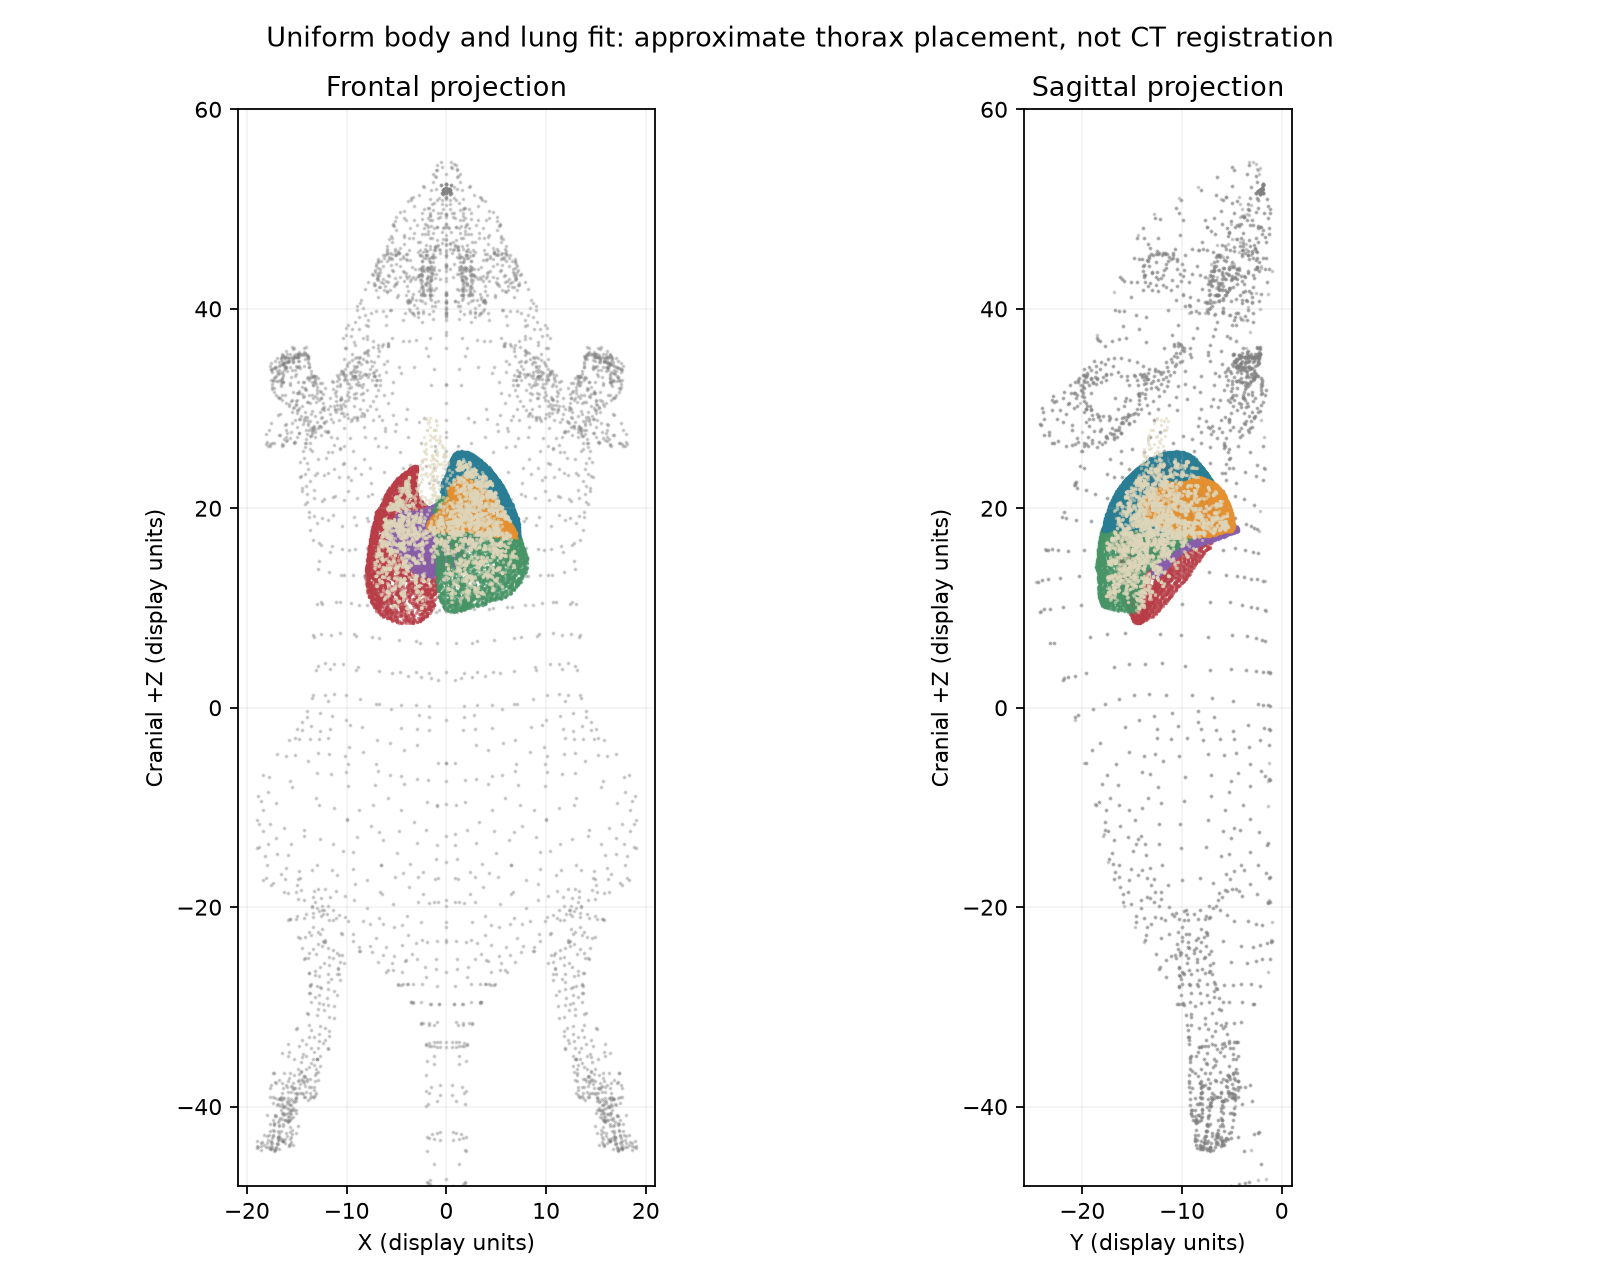

In [7]:
# Validate and visualize exactly the context fit used in JavaScript.
import gzip, base64
payload = json.loads(original_payload)
lobes = [d for d in payload if 'Trachea' not in d['name']]
lo = np.min([d['min'] for d in lobes], axis=0)
hi = np.max([d['max'] for d in lobes], axis=0)
tlo = np.array([-.85,-1.65,.55])*11.8
thi = np.array([.85,-.30,2.35])*11.8
fit = .9 * np.min((thi-tlo)/(hi-lo))
shift = (thi+tlo)/2 - fit*(lo+hi)/2
assert np.all(lo*fit+shift >= tlo) and np.all(hi*fit+shift <= thi)
body_display = corrected*11.8
fig, axes = plt.subplots(1,2,figsize=(10,8))
for ax,(a,b),title in zip(axes,[(0,2),(1,2)],['Frontal projection','Sagittal projection']):
    ax.scatter(body_display[:,a],body_display[:,b],s=.5,color='gray',alpha=.35)
    for d in payload:
        q=np.frombuffer(gzip.decompress(base64.b64decode(d['q_b64'])),dtype='<u2').reshape(-1,3)
        xyz=np.array(d['min'])+q/65535*(np.array(d['max'])-d['min'])
        xyz=xyz[::max(1,len(xyz)//4000)]*fit+shift
        ax.scatter(xyz[:,a],xyz[:,b],s=.3,color=d['color'],alpha=.55)
    ax.set_aspect('equal'); ax.set(title=title,xlabel='XYZ'[a]+' (display units)',ylabel='Cranial +Z (display units)',ylim=(-48,60))
    ax.grid(alpha=.15)
fig.suptitle('Uniform body and lung fit: approximate thorax placement, not CT registration')
fig.tight_layout(); fig.savefig(OUT/'body_lung_placement_audit.png',dpi=160);plt.close(fig)
display(Image(filename=str(OUT/'body_lung_placement_audit.png')))
report.update(lung_context_scale=float(fit),lung_context_translation=shift.tolist(),lung_bbox_inside_thorax_envelope=True)
report_path.write_text(json.dumps(report,indent=2))
print('Lobe fit scale:',fit,'; position:',shift.tolist())
print('Lung-only vertices unchanged. Live browser interaction remains untested.')

## True two-dimensional section preview

Intersect every triangle with the selected plane in unchanged lung-local millimeter coordinates, project intersection segments into the same in-plane basis used by the plane widget, and stitch endpoints (rounding tolerance 0.00001 mm). Closed loops use even-odd filling, retaining nested holes; open contours remain outlines and are reported. Coplanar faces are not filled as separate surfaces. This is an infinitesimal anatomical surface section, not a histology simulator or a 5 µm voxel slab. All supplied meshes are shown independent of 3D visibility.

The day buttons display measured DAPI sections and hide the unrelated illustrative plane. Exact day-specific 3D planes cannot be assigned from the available provenance. No automatic shape registration or invented plane is substituted.

In [8]:
# Replace the oblique 3D inset with the actual plane / triangle intersection.
import time
BUILD = Path(os.environ.get('LUNG_VIEWER_OUTPUT',str(DEST)))
viewer=BUILD.read_text()
slice_js="// Plane/triangle intersection in unmodified lung coordinates.\nfunction sectionContours(pos,idx,n,u,v,depth){\n const count=pos.length/3, ds=new Float64Array(count), xx=new Float64Array(count), yy=new Float64Array(count);\n for(let i=0;i<count;i++){const x=pos[3*i],y=pos[3*i+1],z=pos[3*i+2];ds[i]=x*n[0]+y*n[1]+z*n[2]-depth;xx[i]=x*u[0]+y*u[1]+z*u[2];yy[i]=x*v[0]+y*v[1]+z*v[2];}\n const nodes=[],edges=[],lookup=new Map(), seen=new Set();\n const node=p=>{const key=Math.round(p[0]*1e5)+','+Math.round(p[1]*1e5);if(!lookup.has(key)){lookup.set(key,nodes.length);nodes.push({p,edges:[]});}return lookup.get(key);};\n for(let t=0;t<idx.length;t+=3){const ids=[idx[t],idx[t+1],idx[t+2]],hits=[];\n  for(let e=0;e<3;e++){const a=ids[e],b=ids[(e+1)%3];if((ds[a]>=0)===(ds[b]>=0))continue;const f=ds[a]/(ds[a]-ds[b]);hits.push([xx[a]+f*(xx[b]-xx[a]),yy[a]+f*(yy[b]-yy[a])]);}\n  if(hits.length!==2)continue;const a=node(hits[0]),b=node(hits[1]);if(a===b)continue;const key=Math.min(a,b)+':'+Math.max(a,b);if(seen.has(key))continue;seen.add(key);const e=edges.length;edges.push([a,b]);nodes[a].edges.push(e);nodes[b].edges.push(e);\n }\n const used=new Uint8Array(edges.length),loops=[],open=[];\n for(let e=0;e<edges.length;e++){if(used[e])continue;let start=edges[e][0],cur=start,k=e;const path=[nodes[start].p];let closed=false;\n  while(k!==undefined&&!used[k]){used[k]=1;const ab=edges[k];cur=ab[0]===cur?ab[1]:ab[0];path.push(nodes[cur].p);if(cur===start){closed=true;break;}k=nodes[cur].edges.find(j=>!used[j]);}\n  (closed?loops:open).push(path);\n }\n return {loops,open,segments:edges.length};\n}\nvar sliceTimer=null;\nfunction scheduleSlice(){\n const panel=document.getElementById('slicePanel');panel.hidden=!clipping;\n clearTimeout(sliceTimer);if(!clipping)return;\n document.getElementById('sliceStatus').textContent='Computing plane intersection…';\n sliceTimer=setTimeout(drawSlice,160);\n}\nfunction drawSlice(){\n if(!clipping)return;\n const a=sectionAngle*Math.PI/180,b=sectionTilt*Math.PI/180;\n const normal=new THREE.Vector3(Math.cos(b)*Math.cos(a),Math.cos(b)*Math.sin(a),Math.sin(b));\n const helper=Math.abs(normal.z)<.96?new THREE.Vector3(0,0,1):new THREE.Vector3(0,1,0);\n const u=new THREE.Vector3().crossVectors(helper,normal).normalize(),v=new THREE.Vector3().crossVectors(normal,u).normalize();\n const results=[...lobeMeshes,airwayMesh].filter(Boolean).map(m=>({name:m.name,color:'#'+m.material.color.getHexString(),...sectionContours(m.geometry.attributes.position.array,m.geometry.index.array,normal.toArray(),u.toArray(),v.toArray(),sectionDepth)}));\n const canvas=document.getElementById('sliceCanvas'),ctx=canvas.getContext('2d');ctx.fillStyle='#080d12';ctx.fillRect(0,0,canvas.width,canvas.height);\n const points=results.flatMap(r=>[...r.loops,...r.open].flat());\n if(!points.length){document.getElementById('sliceStatus').textContent='No mesh intersection at this plane.';return;}\n let xmin=Infinity,xmax=-Infinity,ymin=Infinity,ymax=-Infinity;\n points.forEach(p=>{xmin=Math.min(xmin,p[0]);xmax=Math.max(xmax,p[0]);ymin=Math.min(ymin,p[1]);ymax=Math.max(ymax,p[1]);});\n const scale=Math.min(580/Math.max(xmax-xmin,.01),450/Math.max(ymax-ymin,.01)),cx=(xmin+xmax)/2,cy=(ymin+ymax)/2;\n const trace=path=>{path.forEach((p,i)=>{const x=320+(p[0]-cx)*scale,y=260-(p[1]-cy)*scale;i?ctx.lineTo(x,y):ctx.moveTo(x,y);});};\n results.forEach(r=>{ctx.beginPath();r.loops.forEach(path=>{trace(path);ctx.closePath();});ctx.fillStyle=r.color;ctx.fill('evenodd');ctx.strokeStyle=r.color;ctx.lineWidth=1.2;ctx.stroke();ctx.beginPath();r.open.forEach(trace);ctx.stroke();});\n ctx.fillStyle='#ecf3fa';ctx.font='15px sans-serif';ctx.fillText('2 mm',30,545);ctx.fillRect(30,520,2*scale,3);\n const fmt=q=>q.toArray().map(x=>x.toFixed(2)).join(', ');\n document.getElementById('sliceStatus').textContent=`Offset ${sectionDepth.toFixed(2)} mm | ${results.reduce((s,r)=>s+r.loops.length,0)} closed contours | ${results.reduce((s,r)=>s+r.open.length,0)} open paths (outline only). Screen right u=[${fmt(u)}]; up v=[${fmt(v)}] in (R,V,Cr).`;\n}\n"

start=viewer.index('    if(clipping){\n      updateInsetCamera();')
end=viewer.index('    requestAnimationFrame(render)',start)
viewer=viewer[:start]+viewer[end:]
panel='<aside id="slicePanel" class="panel" hidden style="right:16px;top:155px;width:min(420px,calc(100vw - 32px));max-height:calc(100vh - 175px);overflow:auto;padding:14px;z-index:35"><h2 style="font-size:16px">2D section · current reference plane</h2><canvas id="sliceCanvas" width="640" height="570" style="width:100%;background:#080d12"></canvas><div id="sliceStatus" class="small"></div><p class="small">All lobes and airway mesh, regardless of 3D visibility. Colors identify lobes. This is an anatomical mesh section, not simulated IF/Xenium: cells, alveoli and expression are unavailable. Airway color denotes the supplied surface intersection, not a validated lumen.</p></aside>'
viewer=viewer.replace('<aside id="sectionEvidence"',panel+'\n  <aside id="sectionEvidence"',1)
viewer=viewer.replace('  function updateSection(){',slice_js+'\n  function updateSection(){',1)
viewer=viewer.replace('    updatePlaneDescriptor(normal);','    updatePlaneDescriptor(normal);\n    scheduleSlice();',1)
viewer=viewer.replace('an additional inset shows the clipped section from an oblique angle','a 2D panel shows the triangle-mesh intersection with that exact plane')
# Do not let the current illustrative plane masquerade as a day-specific registration.
viewer=viewer.replace("function showSection(day){const panel=", "function showSection(day){clipping=false;sectionVisible=false;sectionGroup.visible=false;document.getElementById('toggleClip').textContent='Clip';document.getElementById('toggleClip').classList.remove('active');document.getElementById('toggleSection').textContent='Show plane';updateSection();const panel=",1)
viewer=viewer.replace("+' · section plane unknown'", "+' · observed 2D section; 3D plane unavailable'",1)
viewer=viewer.replace('Lobe: not reported. Plane normal, offset and block depth: not established.', 'Exact plane cannot be placed on this unrelated 3D mouse: lobe, normal, offset and block depth are not established. The illustrative plane is hidden. Requires oriented block-face / serial sections or specimen-specific registration.')
viewer=viewer.replace("clipping=!clipping;e.currentTarget","clipping=!clipping;if(clipping){document.getElementById('sectionEvidence').hidden=true;sectionVisible=true;sectionGroup.visible=true;document.getElementById('toggleSection').textContent='Hide plane';}e.currentTarget",1)
module=re.search(r'<script type="module">(.*?)</script>',viewer,re.S)[1]
check=subprocess.run(['node','--input-type=module','--check'],input=module,text=True,capture_output=True)
assert check.returncode==0,check.stderr
assert re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S)[1]==original_payload
BUILD.write_text(viewer)
# Analytic validation of the exact JavaScript kernel: cube, off-plane, nested shells.
kernel=slice_js[:slice_js.index('var sliceTimer')]
test=r"""
const p=[-1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,-1,1,1,-1,1,1,1,1,-1,1,1];
const f=[0,2,1,0,3,2,4,5,6,4,6,7,0,1,5,0,5,4,1,2,6,1,6,5,2,3,7,2,7,6,3,0,4,3,4,7];
const cut=(p,f,z)=>sectionContours(p,f,[0,0,1],[1,0,0],[0,1,0],z);
const area=l=>Math.abs(l.slice(1).reduce((s,q,i)=>s+l[i][0]*q[1]-q[0]*l[i][1],0)/2);
const c=cut(p,f,0);if(c.loops.length!==1||c.open.length||Math.abs(area(c.loops[0])-4)>1e-8)throw Error('cube');
if(cut(p,f,3).segments!==0)throw Error('empty');
const h=cut(p.concat(p.map(x=>x*.5)),f.concat(f.map(i=>i+8)),0);
if(h.loops.length!==2||h.open.length)throw Error('nested shells');
console.log(JSON.stringify({cube_area:area(c.loops[0]),nested_loops:h.loops.length,empty:true}));
"""
check=subprocess.run(['node'],input=kernel+test,text=True,capture_output=True)
assert check.returncode==0,check.stderr
report.update(output_sha256=hashlib.sha256(viewer.encode()).hexdigest(),section_panel='exact_triangle_plane_intersection_with_evenodd_closed_contours',section_kernel_tests=json.loads(check.stdout),day_buttons='observed_DAPI_only_unregistered_plane_hidden')
report_path.write_text(json.dumps(report,indent=2))
print('Section kernel tests:',check.stdout.strip())
print('JavaScript syntax passed. Day-specific exact planes remain unavailable.')

Section kernel tests: {"cube_area":4,"nested_loops":2,"empty":true}
JavaScript syntax passed. Day-specific exact planes remain unavailable.


[
  {
    "plane": "Screenshot plane",
    "elapsed_ms": 62,
    "closed": 22,
    "open": 0
  },
  {
    "plane": "Sagittal",
    "elapsed_ms": 45,
    "closed": 15,
    "open": 0
  },
  {
    "plane": "Dorsal",
    "elapsed_ms": 34,
    "closed": 42,
    "open": 6
  },
  {
    "plane": "Transverse",
    "elapsed_ms": 35,
    "closed": 37,
    "open": 0
  }
]


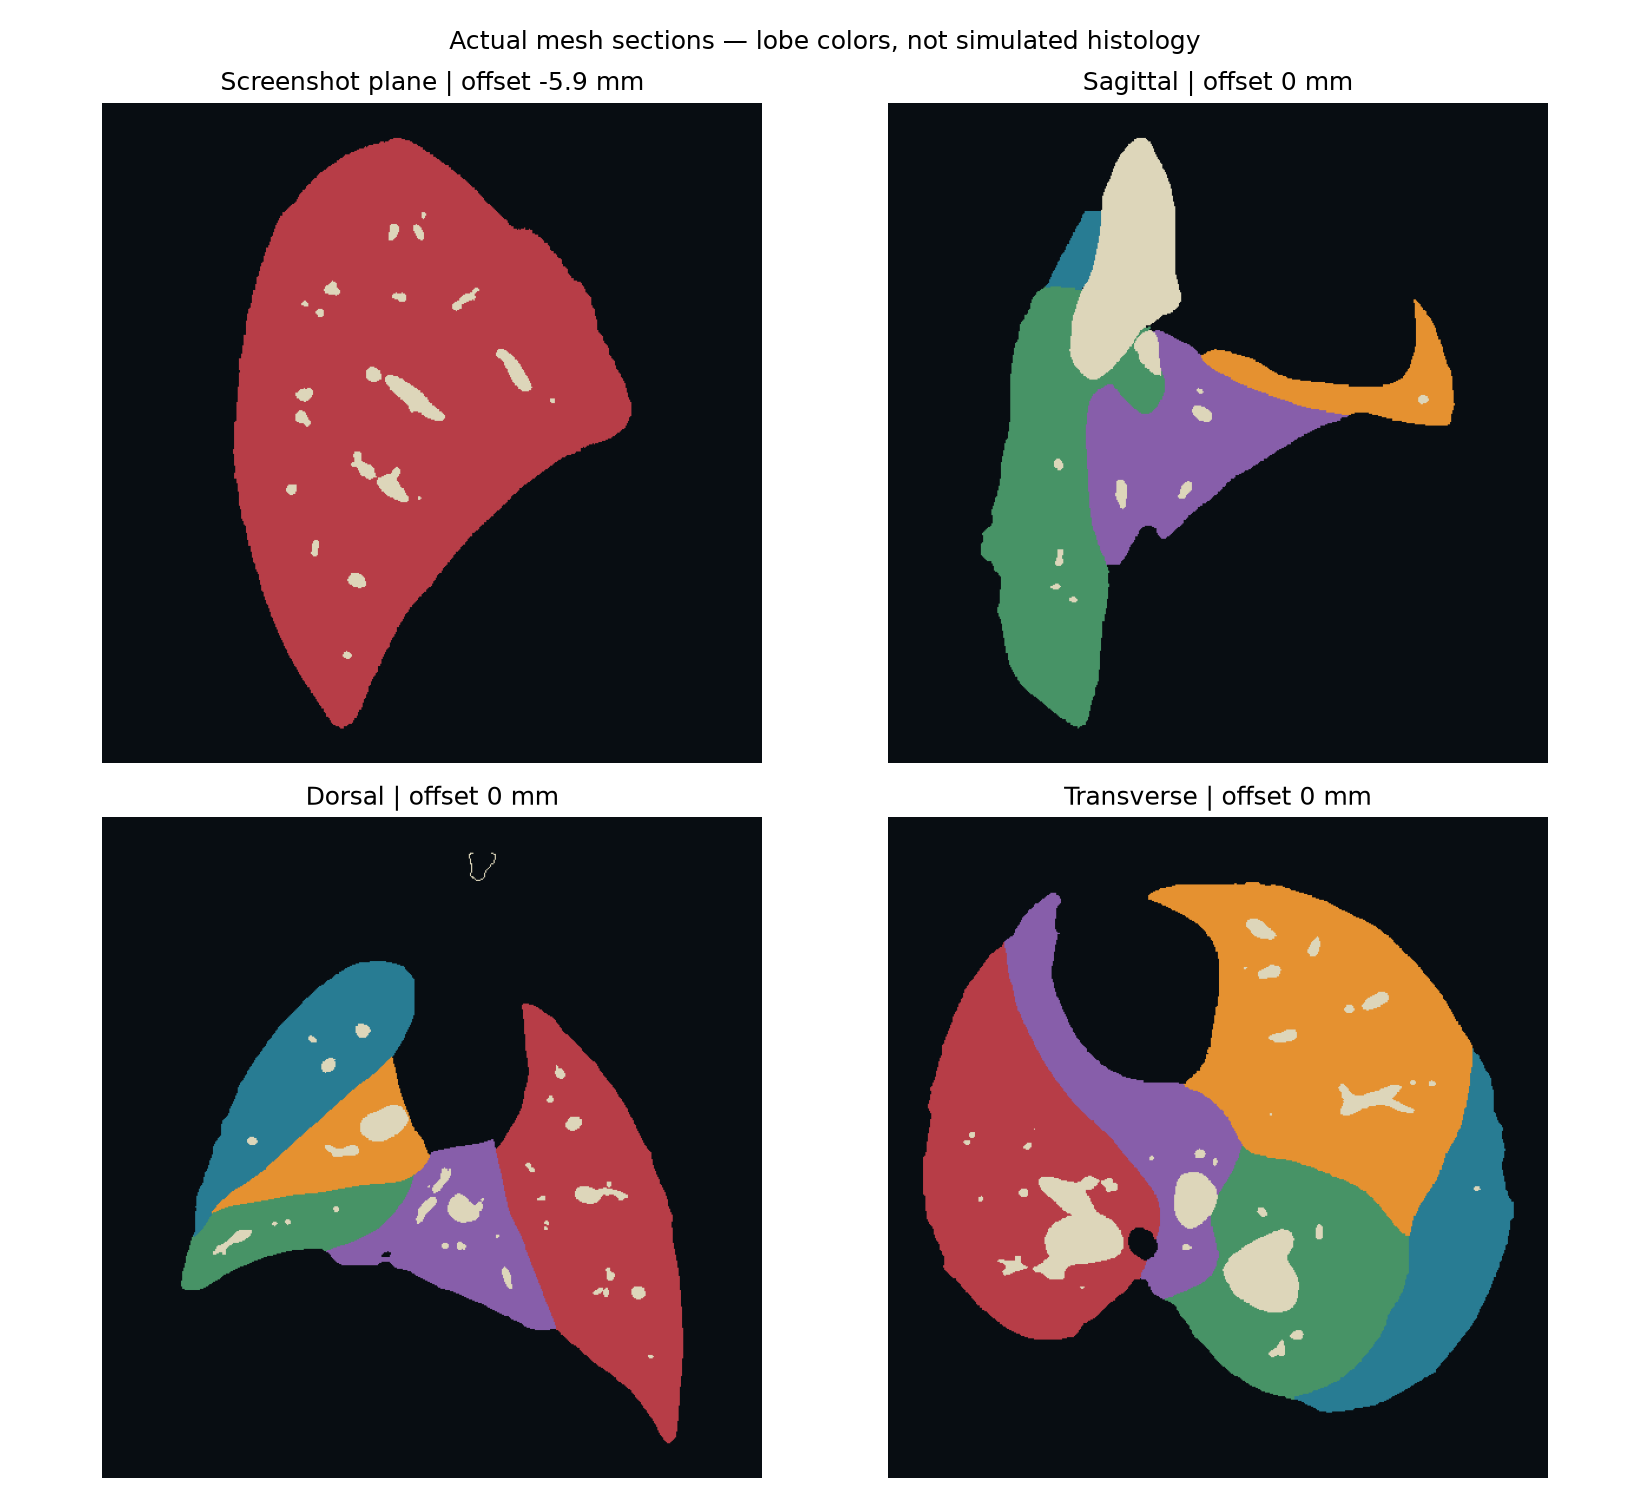

In [9]:
# Execute the identical JS kernel on the actual full-resolution meshes.
actual_test = r"""
const zlib=require('zlib');
const meshes=PAYLOAD.map(d=>{const qb=zlib.gunzipSync(Buffer.from(d.q_b64,'base64')),ib=zlib.gunzipSync(Buffer.from(d.i_b64,'base64'));const p=new Float32Array(qb.length/2),idx=new Uint32Array(ib.length/4);for(let i=0;i<p.length;i++)p[i]=d.min[i%3]+qb.readUInt16LE(2*i)/65535*(d.max[i%3]-d.min[i%3]);for(let i=0;i<idx.length;i++)idx[i]=ib.readUInt32LE(4*i);return {p,idx,name:d.name,color:d.color};});
const configs=[['Screenshot plane',15,0,-5.9],['Sagittal',0,0,0],['Dorsal',90,0,0],['Transverse',0,90,0]];
const cross=(a,b)=>[a[1]*b[2]-a[2]*b[1],a[2]*b[0]-a[0]*b[2],a[0]*b[1]-a[1]*b[0]];
const norm=a=>{const l=Math.hypot(...a);return a.map(x=>x/l);};
const results=configs.map(([name,a,b,depth])=>{a*=Math.PI/180;b*=Math.PI/180;const n=[Math.cos(b)*Math.cos(a),Math.cos(b)*Math.sin(a),Math.sin(b)],u=norm(cross(Math.abs(n[2])<.96?[0,0,1]:[0,1,0],n)),v=norm(cross(n,u));const start=Date.now();return {name,depth,meshes:meshes.map(m=>({name:m.name,color:m.color,...sectionContours(m.p,m.idx,n,u,v,depth)})),elapsed_ms:Date.now()-start};});
console.log(JSON.stringify(results));
""".replace('PAYLOAD',original_payload)
check=subprocess.run(['node'],input=kernel+actual_test,text=True,capture_output=True)
assert check.returncode==0,check.stderr
sections=json.loads(check.stdout)
from PIL import Image as PILImage, ImageDraw, ImageChops
fig,axes=plt.subplots(2,2,figsize=(11,10))
validation=[]
for ax,s in zip(axes.flat,sections):
    points=np.array([p for m in s['meshes'] for loop in m['loops']+m['open'] for p in loop])
    low=points.min(0);high=points.max(0);center=(low+high)/2;zoom=500/max(high-low)
    canvas=PILImage.new('RGB',(560,560),'#080d12')
    for m in s['meshes']:
        parity=PILImage.new('1',canvas.size,0)
        for loop in m['loops']:
            poly=(np.array(loop)-center)*[zoom,-zoom]+280
            mask=PILImage.new('1',canvas.size,0);ImageDraw.Draw(mask).polygon([tuple(p) for p in poly],fill=1)
            parity=ImageChops.logical_xor(parity,mask)
        canvas.paste(tuple(int(255*c) for c in m['color']),(0,0,560,560),parity)
        draw=ImageDraw.Draw(canvas)
        for loop in m['open']:
            poly=(np.array(loop)-center)*[zoom,-zoom]+280
            draw.line([tuple(p) for p in poly],fill=tuple(int(255*c) for c in m['color']),width=1)
    ax.imshow(canvas);ax.set_title(s['name']+' | offset '+str(s['depth'])+' mm');ax.axis('off')
    validation.append(dict(plane=s['name'],elapsed_ms=s['elapsed_ms'],closed=sum(len(m['loops']) for m in s['meshes']),open=sum(len(m['open']) for m in s['meshes'])))
fig.suptitle('Actual mesh sections — lobe colors, not simulated histology')
fig.tight_layout();fig.savefig(OUT/'plane_section_audit.png',dpi=150);plt.close(fig)
display(Image(filename=str(OUT/'plane_section_audit.png')))
report['actual_mesh_section_validation']=validation
report_path.write_text(json.dumps(report,indent=2))
print(json.dumps(validation,indent=2))

## Model-bound plane addresses (LP1)

A plane is represented by a unit normal **n** and a signed offset **d**, with equation **n·x=d**. Coordinates are local model millimeters in (+right,+ventral,+cranial), origin unchanged from the hashed geometry payload. The LP1 format includes its version, full SHA-256 geometry fingerprint, frame ID, units and deterministic screen-basis convention. It is a documented application format, not a GPS/DICOM standard or a registration to a specific Xenium sample. It is independent of whole-body display scale/position.

Normals are serialized to 10 decimal places and offsets to 6; this numerical precision does not imply micrometer biological accuracy. Orientation n and offset -n/-d describe the same unoriented plane but opposite clipping sides; exported normals use the existing slider hemisphere (+X). Paste validates the fingerprint and coordinate schema before changing the view. Copy ID is portable between matching viewers. Copy link can restore from the URL fragment, but a local file URL is not portable between different filesystem paths. The actual section frame is reconstructed, not camera/visibility preferences.

In [10]:
# Versioned, model-bound coordinate address. This is an application format, not a standard atlas ID.
BUILD=Path(os.environ.get('LUNG_VIEWER_OUTPUT',str(DEST)))
viewer=BUILD.read_text()
model_hash=hashlib.sha256(original_payload.encode()).hexdigest()
plane_js="const PLANE_MODEL='__HASH__';\nfunction encodePlane(a,b,d){\n const r=Math.PI/180,n=[Math.cos(b*r)*Math.cos(a*r),Math.cos(b*r)*Math.sin(a*r),Math.sin(b*r)].map(x=>+x.toFixed(10));\n return 'LP1.'+btoa(JSON.stringify({v:1,model:PLANE_MODEL,frame:'local-RVCR-v1',unit:'mm',n,d:+d.toFixed(6),basis:'helper-up-v1'})).replaceAll('+','-').replaceAll('/','_').replace(/=+$/,'');\n}\nfunction decodePlane(text){\n let id=text.trim();if(id.includes('#'))id=decodeURIComponent(id.slice(id.indexOf('#')+1));if(id.startsWith('plane='))id=id.slice(6);\n if(id.length>3000||!/^LP1\\.[A-Za-z0-9_-]+$/.test(id))throw Error('Paste a valid LP1 ID or viewer link.');\n const b=id.slice(4).replaceAll('-','+').replaceAll('_','/');let p;\n try{p=JSON.parse(atob(b+'='.repeat((4-b.length%4)%4)));}catch(e){throw Error('Invalid plane encoding.');}\n if(p.v!==1||p.model!==PLANE_MODEL||p.frame!=='local-RVCR-v1'||p.unit!=='mm'||p.basis!=='helper-up-v1')throw Error('Model fingerprint, frame, version or units do not match this viewer.');\n if(!Array.isArray(p.n)||p.n.length!==3||!p.n.every(x=>typeof x==='number'&&Number.isFinite(x))||typeof p.d!=='number'||!Number.isFinite(p.d)||Math.abs(p.d)>1000||Math.abs(Math.hypot(...p.n)-1)>1e-7||p.n[0]<-1e-10)throw Error('Invalid normal or offset.');\n const a=Math.atan2(p.n[1],p.n[0])*180/Math.PI,beta=Math.asin(Math.max(-1,Math.min(1,p.n[2])))*180/Math.PI;\n if(Math.abs(a)>90.000001)throw Error('Unsupported normal hemisphere.');\n return {a,b:beta,d:p.d,p};\n}\nfunction refreshPlaneAddress(){const el=document.getElementById('planeAddress');if(el)el.value=encodePlane(sectionAngle,sectionTilt,sectionDepth);}\nfunction loadPlaneAddress(text){\n const s=decodePlane(text);sectionAngle=s.a;sectionTilt=s.b;sectionDepth=s.d;\n for(const [id,value] of [['angle',s.a],['angle2',s.b],['depth',s.d]]){const el=document.getElementById(id);el.min=Math.min(+el.min,value);el.max=Math.max(+el.max,value);el.step='any';el.value=value;document.getElementById(id+'Out').value=value.toFixed(4)+(id==='depth'?'':'°');}\n sectionVisible=true;sectionGroup.visible=true;clipping=true;document.getElementById('sectionEvidence').hidden=true;\n document.getElementById('toggleSection').textContent='Hide plane';document.getElementById('toggleClip').textContent='Unclip';document.getElementById('toggleClip').classList.add('active');\n stopAutoRotateByUser();updateSection();document.getElementById('planeAddressStatus').textContent='Restored in the reference lung frame; CT body placement does not change this address.';\n}\nasync function copyPlaneAddress(link){\n const id=encodePlane(sectionAngle,sectionTilt,sectionDepth),text=link?location.href.split('#')[0]+'#plane='+id:id;\n const box=document.getElementById('planePaste');box.value=text;\n try{await navigator.clipboard.writeText(text);document.getElementById('planeAddressStatus').textContent=link?'Viewer link copied. Local-file links require the same file path; use the ID on another computer.':'Plane ID copied; paste into any matching viewer.';}\n catch(e){box.focus();box.select();document.getElementById('planeAddressStatus').textContent='Clipboard unavailable: selected below; press Ctrl/Cmd+C.';}\n}\n".replace('__HASH__',model_hash)
setup_js="  document.getElementById('copyPlaneID').addEventListener('click',()=>copyPlaneAddress(false));\n  document.getElementById('copyPlaneLink').addEventListener('click',()=>copyPlaneAddress(true));\n  function tryLoadPlane(text){try{loadPlaneAddress(text);}catch(e){document.getElementById('planeAddressStatus').textContent=e.message;}}\n  document.getElementById('loadPlaneID').addEventListener('click',()=>tryLoadPlane(document.getElementById('planePaste').value));\n  window.addEventListener('hashchange',()=>{if(location.hash.startsWith('#plane='))tryLoadPlane(location.hash);});\n  if(location.hash.startsWith('#plane='))tryLoadPlane(location.hash);\n  refreshPlaneAddress();\n"
address_html='<details class="miniDetails" open><summary>Scientific plane address</summary><div class="miniBody"><div class="small">Reference lung frame: +X right, +Y ventral, +Z cranial; mm. Plane n·x = d. Origin belongs to this exact mesh, not the body or Xenium slide.</div><textarea id="planeAddress" readonly aria-label="Current plane ID" style="width:100%;height:52px"></textarea><div class="btnGrid two"><button id="copyPlaneID">Copy plane ID</button><button id="copyPlaneLink">Copy link</button></div><textarea id="planePaste" placeholder="Paste LP1 ID or viewer link" aria-label="Plane address to restore" style="width:100%;height:58px"></textarea><button id="loadPlaneID">Restore plane</button><div id="planeAddressStatus" class="small" aria-live="polite"></div></div></details>'
viewer=viewer.replace('  function updateSection(){',plane_js+'\n  function updateSection(){',1)
viewer=viewer.replace('    scheduleSlice();','    scheduleSlice();\n    refreshPlaneAddress();',1)
viewer=viewer.replace('    <div class="control"><label for="depth">',address_html+'\n    <div class="control"><label for="depth">',1)
viewer=viewer.replace('  function render(){',setup_js+'\n  function render(){',1)
module=re.search(r'<script type="module">(.*?)</script>',viewer,re.S)[1]
check=subprocess.run(['node','--input-type=module','--check'],input=module,text=True,capture_output=True);assert check.returncode==0,check.stderr
codec=plane_js[:plane_js.index('function refreshPlaneAddress')]
tests=r"""
let maxError=0;
for(const a of [-90,-45,0,15,89,90])for(const b of [-90,-30,0,35,90])for(const d of [-10,-5.9,0,10]){
 const id=encodePlane(a,b,d),p=decodePlane(id),q=decodePlane('https://example.org/view.html#plane='+id);
 const r=Math.PI/180,n=[Math.cos(b*r)*Math.cos(a*r),Math.cos(b*r)*Math.sin(a*r),Math.sin(b*r)],n2=[Math.cos(p.b*r)*Math.cos(p.a*r),Math.cos(p.b*r)*Math.sin(p.a*r),Math.sin(p.b*r)];maxError=Math.max(maxError,...n.map((x,i)=>Math.abs(x-n2[i])));if(Math.abs(p.d-d)>1e-6||q.d!==p.d)throw Error('roundtrip');}
let rejected=0;for(const bad of ['LP1.abc','junk',encodePlane(0,0,0).replace('LP1','LP2')]){try{decodePlane(bad);}catch(e){rejected++;}}
const p=decodePlane(encodePlane(15,0,-5.9)).p;p.model='wrong';try{decodePlane('LP1.'+btoa(JSON.stringify(p)).replaceAll('+','-').replaceAll('/','_').replace(/=+$/,''));}catch(e){rejected++;}
if(maxError>1e-8||rejected!==4)throw Error('validation');
console.log(JSON.stringify({cases:120,max_normal_error:maxError,invalid_rejected:rejected,example:encodePlane(15,0,-5.9)}));
"""
check=subprocess.run(['node'],input=codec+tests,text=True,capture_output=True);assert check.returncode==0,check.stderr
address_tests=json.loads(check.stdout)
viewer=viewer.replace('Mouse lung explorer · v26','Mouse lung explorer · v27').replace('v26 · C57BL/6 m07','v27 · C57BL/6 m07')
BUILD.write_text(viewer)
report.update(output_sha256=hashlib.sha256(viewer.encode()).hexdigest(),plane_address={'schema':'LP1','model_sha256':model_hash,'frame':'local-RVCR-v1','equation':'dot(n,x)=d','unit':'mm','normal_decimal_places':10,'offset_decimal_places':6,'tests':address_tests})
report_path=OUT/'v27_build_report.json'
report_path.write_text(json.dumps(report,indent=2))
print(json.dumps(address_tests,indent=2))

{
  "cases": 120,
  "max_normal_error": 4.895406302551919e-11,
  "invalid_rejected": 4,
  "example": "LP1.eyJ2IjoxLCJtb2RlbCI6ImE0YWZmMTg4M2IyMWYyOWZlMjk1MzI5M2MxNTc1MzA2NDk0MGQ3NzIxYjdjODMyNzUzMWE0YzNjYmFiOTdkOGUiLCJmcmFtZSI6ImxvY2FsLVJWQ1ItdjEiLCJ1bml0IjoibW0iLCJuIjpbMC45NjU5MjU4MjYzLDAuMjU4ODE5MDQ1MSwwXSwiZCI6LTUuOSwiYmFzaXMiOiJoZWxwZXItdXAtdjEifQ"
}


## Exploratory day-specific plane hypotheses — outer silhouette only

This is an intentionally limited geometric search, not specimen registration. Downsample the source lobe labelmap by 8 in each direction and reslice on a 0.25 mm plane grid. Search azimuths every 15 degrees, elevations every 15 degrees and offsets every 2 mm. Compare DAPI-derived tissue outer masks to the complete reference slice and to each single-lobe slice, allowing in-plane rotation, reflection and uniform scale via PCA normalization. Do not warp the tissue or infer molecular anatomy. Fill holes for this first screen: DAPI gaps are not validated airway lumens, and the lobe map contains no alveolar detail. Therefore the current ranking does **not** validate airway/hole correspondence.

Report three spatially separated candidates per day. IoU is shape agreement after normalization, not a probability or anatomical confidence. The same acquired outline can be compatible with multiple lobes, planes and specimen deformations. No candidate is accepted as the true cut; future validation needs branch landmarks, block orientation or serial sections. LP1 IDs locate candidates in the reference model only.

{
  "D14": [
    {
      "azimuth": -90,
      "elevation": -45,
      "offset_mm": -4,
      "lobe": "Right cranial lobe",
      "label": 2,
      "iou": 0.8444216990788127,
      "normal": [
        4.329780281177467e-17,
        -0.7071067811865476,
        -0.7071067811865475
      ]
    },
    {
      "azimuth": 90,
      "elevation": 45,
      "offset_mm": 4,
      "lobe": "Right cranial lobe",
      "label": 2,
      "iou": 0.8444216990788127,
      "normal": [
        4.329780281177467e-17,
        0.7071067811865476,
        0.7071067811865475
      ]
    },
    {
      "azimuth": -45,
      "elevation": -15,
      "offset_mm": 0,
      "lobe": "Right cranial lobe",
      "label": 2,
      "iou": 0.8433981576253838,
      "normal": [
        0.6830127018922194,
        -0.6830127018922193,
        -0.25881904510252074
      ]
    }
  ],
  "D30": [
    {
      "azimuth": 15,
      "elevation": -15,
      "offset_mm": 2,
      "lobe": "Right middle lobe",
      "label": 3,
     

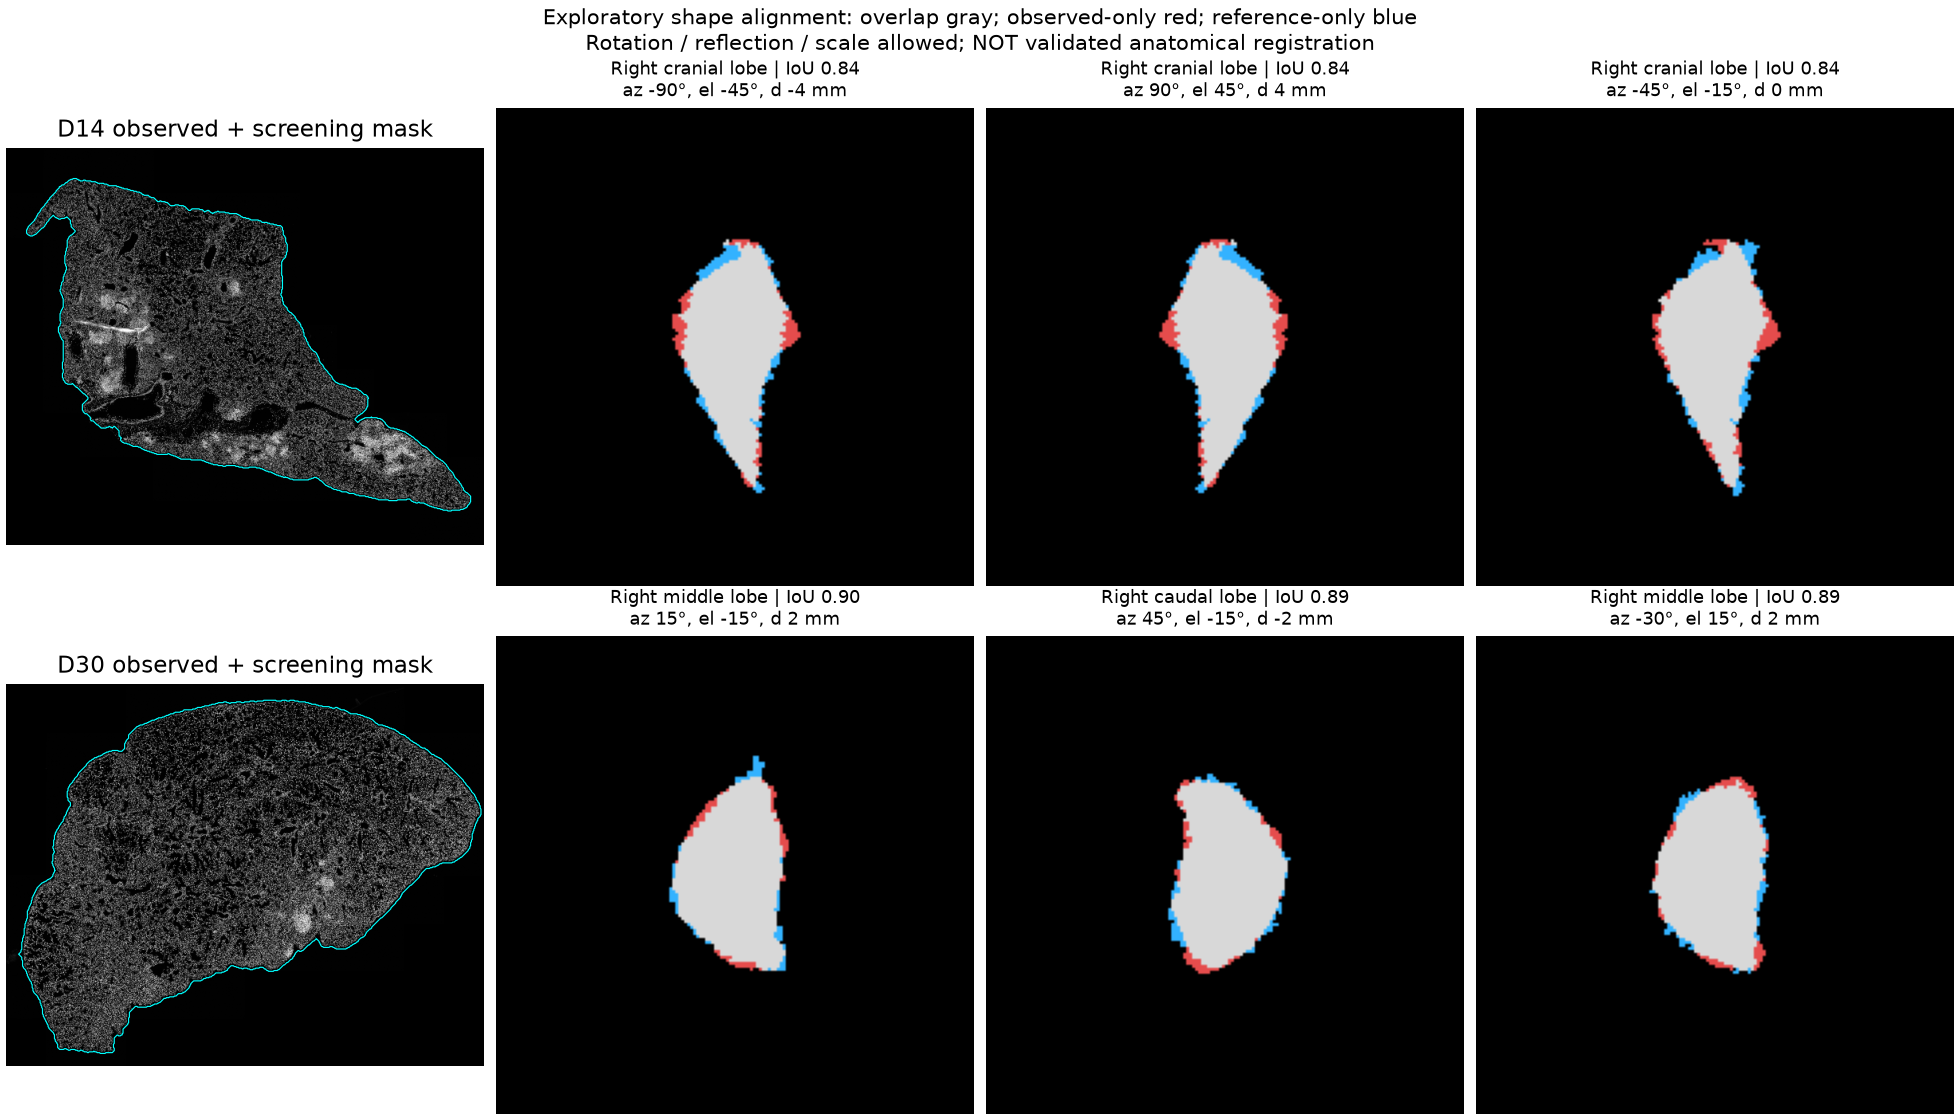

In [11]:
from scipy import ndimage as ndi
import tifffile
# USER CONFIGURATION: add any section name/path here; source images remain untouched.
SECTION_INPUTS = {
    day: {'path': ROOT/f'data/xenium_optional/{day}/explorer/morphology_focus/morphology_focus_0000.ome.tif',
          'level': 4, 'page': 0, 'manual_mask': None}
    for day in ['D14','D30']
}
AZIMUTHS = list(range(-90,91,15))
ELEVATIONS = list(range(-75,91,15))
OFFSETS_MM = list(range(-8,9,2))
PLANE_GRID_MM = .25
LABEL_STRIDE = 8
TOP_CANDIDATES = 3
MASK_MAX_SIDE = 600
BACKGROUND_FRACTION = .10
# Stream downsampled labels, preserving original physical origin and axis directions.
small=[]
with REF.open('rb') as raw:
    raw.seek(offset)
    with gzip.GzipFile(fileobj=raw) as f:
        for z in range(sizes[2]):
            arr=np.frombuffer(f.read(sizes[0]*sizes[1]*2),dtype='<u2').reshape(sizes[1],sizes[0])
            if z%LABEL_STRIDE==0:small.append(arr[::LABEL_STRIDE,::LABEL_STRIDE].copy())
volume=np.stack(small)
def outer_mask(mask):
    lab,k=ndi.label(mask)
    counts=np.bincount(lab.ravel());counts[0]=0
    if not counts.max():return mask
    mask=np.isin(lab,np.flatnonzero(counts>=counts.max()*.03))
    return ndi.binary_fill_holes(mask)
def canonical(mask):
    pts=np.argwhere(mask)
    if len(pts)<30:return None
    center=pts.mean(0);cov=np.cov((pts-center).T)
    eig,axes=np.linalg.eigh(cov);axes=axes[:,::-1]
    # Equal area scale, preserved aspect ratio; PCA defines orientation only.
    scale=np.sqrt(len(pts)/1800)
    yy,xx=np.mgrid[:160,:160];out=np.stack([yy-79.5,xx-79.5],-1)
    coords=(out*scale)@axes.T+center
    return ndi.map_coordinates(mask.astype(float),[coords[:,:,0],coords[:,:,1]],order=0,mode='constant')>0
observed={};targets={}
for day,spec in SECTION_INPUTS.items():
    path=Path(spec['path'])
    if path.suffix.lower() in ['.tif','.tiff']:
        with tifffile.TiffFile(path,is_ome=False) as tf:im=tf.series[0].levels[spec['level']].pages[spec['page']].asarray()
    else:
        im=np.asarray(PILImage.open(path).convert('L'))
    assert im.ndim==2, 'Select one 2D grayscale page/channel first.'
    im=ndi.zoom(im.astype(float),min(1,MASK_MAX_SIDE/max(im.shape)))
    smooth=ndi.gaussian_filter(im,2)
    # Background-relative threshold; an exploratory outer mask, not cell segmentation.
    cut=np.percentile(smooth,10)+BACKGROUND_FRACTION*(np.percentile(smooth,99)-np.percentile(smooth,10))
    mask=outer_mask(ndi.binary_closing(smooth>cut,iterations=3))
    if spec['manual_mask'] is not None:
        manual=np.asarray(PILImage.open(spec['manual_mask']).convert('L'))>0
        mask=ndi.zoom(manual.astype(float),np.array(im.shape)/manual.shape,order=0)>0
    assert mask.sum()>30, 'Tissue mask empty; inspect threshold or supply a manual mask.'
    observed[day]=(im,mask);t=canonical(mask)
    targets[day]=[t,t[::-1],t[:,::-1],t[::-1,::-1]]
translations=np.array(best['translation']);signs=np.array(best['signs'])
grid=np.arange(-15,15.001,PLANE_GRID_MM);yy,xx=np.meshgrid(grid,grid,indexing='ij')
candidates={day:[] for day in targets}
for az in AZIMUTHS:
 for el in ELEVATIONS:
  a,b=np.deg2rad([az,el]);normal=np.array([np.cos(b)*np.cos(a),np.cos(b)*np.sin(a),np.sin(b)])
  helper=np.array([0,0,1] if abs(normal[2])<.96 else [0,1,0]);u=np.cross(helper,normal);u/=np.linalg.norm(u);v=np.cross(normal,u)
  for depth_mm in OFFSETS_MM:
   coords=xx[:,:,None]*u+yy[:,:,None]*v+depth_mm*normal
   indices=((coords-translations)*signs-origin)/(spacing*LABEL_STRIDE)
   lab=ndi.map_coordinates(volume,[indices[:,:,2],indices[:,:,1],indices[:,:,0]],order=0,mode='constant')
   for label in [0,1,2,3,4,5]:
    mask=outer_mask(lab>0 if label==0 else lab==label);can=canonical(mask)
    if can is None:continue
    for day,variants in targets.items():
     scores=[np.logical_and(can,t).sum()/max(1,np.logical_or(can,t).sum()) for t in variants]
     candidates[day].append(dict(azimuth=az,elevation=el,offset_mm=depth_mm,lobe='all' if label==0 else labels[label],label=label,iou=float(max(scores)),normal=normal.tolist(),mask=mask,canonical=can))
selected={}
for day,rows in candidates.items():
    rows.sort(key=lambda r:r['iou'],reverse=True);chosen=[]
    for row in rows:
        if all(np.rad2deg(np.arccos(np.clip(abs(np.dot(row['normal'],r['normal'])),0,1)))>=25 or abs(row['offset_mm']-r['offset_mm'])>=3 for r in chosen):chosen.append(row)
        if len(chosen)==TOP_CANDIDATES:break
    selected[day]=chosen
fig,axs=plt.subplots(len(SECTION_INPUTS),TOP_CANDIDATES+1,figsize=(14,4*len(SECTION_INPUTS)),layout='constrained',squeeze=False)
for i,day in enumerate(SECTION_INPUTS):
    im,mask=observed[day];axs[i,0].imshow(im,cmap='gray');axs[i,0].contour(mask,levels=[.5],colors='cyan',linewidths=.6);axs[i,0].set_title(day+' observed + screening mask')
    for ax,r in zip(axs[i,1:],selected[day]):
        can=r['canonical'];t=max(targets[day],key=lambda t:np.logical_and(t,can).sum()/np.logical_or(t,can).sum());rgb=np.zeros((*can.shape,3));rgb[t]=[.9,.3,.3];rgb[can]=[.2,.7,1];rgb[t&can]=[.85,.85,.85];ax.imshow(rgb);ax.set_title(f"{r['lobe']} | IoU {r['iou']:.2f}\naz {r['azimuth']}°, el {r['elevation']}°, d {r['offset_mm']} mm",fontsize=9)
    for ax in axs[i]:ax.axis('off')
fig.suptitle('Exploratory shape alignment: overlap gray; observed-only red; reference-only blue\nRotation / reflection / scale allowed; NOT validated anatomical registration',fontsize=11)
fig.savefig(OUT/'day_plane_hypotheses.png',dpi=140);plt.close(fig)
display(Image(filename=str(OUT/'day_plane_hypotheses.png')))
plane_hypotheses={day:[{k:v for k,v in r.items() if k not in ['mask','canonical']} for r in rows] for day,rows in selected.items()}
(OUT/'day_plane_hypotheses.json').write_text(json.dumps(plane_hypotheses,indent=2))
print(json.dumps(plane_hypotheses,indent=2))

## Alveolar data search (2026-09-29)

| Source | Verified data / scale | Appropriate use and limitation |
|---|---|---|
| [lapdMouse m07](https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07), [primary paper](https://journals.physiology.org/doi/full/10.1152/japplphysiol.00615.2019) | Same m07 has near-acini labels (8.9 MB) and autofluorescence volume (15.42 GB; Sub4 245.9 MB). Serial block-face acquisition, not a complete alveolar CT atlas. | Best same-specimen next layer. Near-acini partitions are not individual alveolar sacs or septal surfaces. Raw data would require resolution/segmentation validation. |
| [Lovric et al. 2017](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0183979), [declared data DOI](https://doi.org/10.7910/DVN/XO8FQY) | 1.1 and 2.9 µm pixel optics; fields of view 2.2×2.2 and 5.8×2.7 mm. Raw projections declared public by authors. | A promising separate alveolar-region example; not whole-lung m07 geometry. At 2.9 µm septa were lost in segmentation; 1.1 µm is the stronger option. Repository landing page could not be inspected with the web tool; files/download status not independently verified. |
| [Shaker et al., Zenodo v2](https://zenodo.org/records/4584516) | NMRI nude mouse; 8.25 µm voxels; 42.2 GB volume and 30.4 MB sample slice. | Public reconstructed volume; useful for terminal bronchioles. Voxel size alone does not establish faithful individual alveolar walls. Not m07. |
| [LungVis 1.0](https://www.nature.com/articles/s41467-024-54267-1), [data](https://zenodo.org/records/7413818) | 78 murine LSFM datasets, airway segmentations and reference annotations. | Rich independent lung/airway reference; the listing does not establish a full set of individual alveolar meshes registered to m07. |
| [Shin et al. 2023](https://www.nature.com/articles/s41598-023-27627-y) | 2.24 µm effective pixels, local lung apex reconstructions. | Alveolar 3D method; data available on request, not publicly downloadable according to the article. |

**Decision:** do not generate decorative alveoli or label near-acini as alveoli. A defensible implementation is (1) same-m07 near-acini as explicitly named compartments, (2) a separate high-resolution alveolar ROI with its own frame and provenance, (3) optional registration only if correspondence can be demonstrated. Both 3D and plane views can use that validated geometry/volume, but the current model does not contain it. No alveolar layer was added in this step. Complete mouse lung anatomy also requires vasculature, septa and other tissue components absent from these gross meshes.

In [12]:
# Add explicitly hypothetical day candidates and the data-availability panel to v27.
BUILD=Path(os.environ.get('LUNG_VIEWER_OUTPUT',str(DEST)))
viewer=BUILD.read_text()
hypothesis_js="const dayPlaneHypotheses="+json.dumps(plane_hypotheses)+";\n"+r"""
function selectDayCandidate(day,index){
 const c=dayPlaneHypotheses[day][index];loadPlaneAddress(encodePlane(c.azimuth,c.elevation,c.offset_mm));
 document.querySelector('.planeKicker').textContent=day+' candidate '+(index+1)+' — UNVALIDATED silhouette hypothesis';
 document.getElementById('planeAddressStatus').textContent=day+' candidate '+(index+1)+' | screened '+c.lobe+' only | shape IoU '+c.iou.toFixed(3)+'; not anatomical confidence. Full plane preview may include other lobes.';
}
function showSection(day){
 showObservedSection(day);selectDayCandidate(day,0);
 const panel=document.getElementById('sectionEvidence');panel.hidden=false;
 document.getElementById('sectionEvidenceTitle').textContent=day+' observed section + reference hypotheses';
 document.getElementById('sectionEvidenceText').textContent='The visible plane is candidate 1, NOT the measured cut. Outer shape only; rotation, reflection and scale allowed. Hole/airway correspondence not validated. Close this panel to see its 2D mesh section.';
 let list=document.getElementById('dayCandidateList');if(!list){list=document.createElement('div');list.id='dayCandidateList';panel.appendChild(list);}list.replaceChildren();
 dayPlaneHypotheses[day].forEach((c,i)=>{const button=document.createElement('button');button.style.cssText='width:100%;margin-top:8px';button.textContent='Candidate '+(i+1)+' · '+c.lobe+' · shape IoU '+c.iou.toFixed(3);button.addEventListener('click',()=>selectDayCandidate(day,i));list.appendChild(button);});
}
"""
viewer=viewer.replace('function showSection(day){','function showObservedSection(day){',1)
viewer=viewer.replace('  function render(){',hypothesis_js+'\n  function render(){',1)
# Every manual plane update clears any stale day-specific label.
viewer=viewer.replace('    updatePlaneDescriptor(normal);',"    document.querySelector('.planeKicker').textContent='Reference plane — not a measured D14 / D30 registration';\n    updatePlaneDescriptor(normal);",1)
viewer=viewer.replace('Day 14 / 30 sections have no established 3D registration.','Day 14 / 30 buttons show exploratory shape-based plane candidates, not established 3D registration.')
info="""<details class="miniDetails"><summary>Alveoli / air-sac data</summary><div class="miniBody small">No individual alveolar geometry is loaded. m07 provides near-acini compartments, which are not alveolar sacs. Independent micron-scale alveolar datasets cannot be placed into m07 without registration.<br><a href="https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07" target="_blank">m07 same-specimen data</a><br><a href="https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0183979" target="_blank">1.1 µm alveolar ROI study</a><br><a href="https://zenodo.org/records/7413818" target="_blank">LungVis data</a></div></details>"""
viewer=viewer.replace('    <div class="control"><label for="depth">',info+'\n    <div class="control"><label for="depth">',1)
module=re.search(r'<script type="module">(.*?)</script>',viewer,re.S)[1]
check=subprocess.run(['node','--input-type=module','--check'],input=module,text=True,capture_output=True);assert check.returncode==0,check.stderr
assert re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S)[1]==original_payload
# Candidate IDs are generated by the exact same browser codec and persisted for reproducibility.
for day,rows in plane_hypotheses.items():
    for r in rows:
        check=subprocess.run(['node'],input=codec+f"\nconsole.log(encodePlane({r['azimuth']},{r['elevation']},{r['offset_mm']}));",text=True,capture_output=True)
        assert check.returncode==0,check.stderr;r['plane_id']=check.stdout.strip()
(OUT/'day_plane_hypotheses.json').write_text(json.dumps(plane_hypotheses,indent=2))
BUILD.write_text(viewer)
report.update(output_path=str(DEST),output_sha256=hashlib.sha256(viewer.encode()).hexdigest(),version=27,day_buttons='top_three_unvalidated_outer_silhouette_hypotheses',alveolar_layer='not_added_no_validated_same_frame_geometry')
(OUT/'v27_build_report.json').write_text(json.dumps(report,indent=2))
print('Built v27:',BUILD)
print('LP1 addresses, day hypotheses and alveolar data notes included. V26 file preserved.')

Built v27: /private/tmp/mouse_lung_3d_blender_detail_v27_anatomy_reference.html
LP1 addresses, day hypotheses and alveolar data notes included. V26 file preserved.
